# Diabetes Health Indicators: UCI Repository - Exploratory Data Analysis

## By: Martin Gayd, Mohamed Salama, Ibrahim Hussein

### Project Overview

This notebook is the final report for the **DSCI 2410 – Fundamentals of Data Science II** capstone project.  
We conduct a comprehensive analysis of the **CDC Diabetes Health Indicators** dataset to understand how
socio-demographic and health-related factors are associated with diabetes status and to build a predictive model.

The notebook is organized to follow the structure requested in the project handout:

1. Research Questions & Objectives  
2. Dataset Description  
3. Data Preparation and Cleaning  
4. Statistical Analysis and Hypothesis Testing  
5. Exploratory Data Analysis & Visualization  
6. Predictive Modeling: Predicting Diabetes  
7. Interpretation and Conclusions  
8. References  


### Abstract:

Diabetes is a life-threatening disease that is caused by several factors. Doctors claim that early diagnosis for this illness contribute significantly to the ability of the patient to live their lives more comfortably through taking precautious measures, although it has no available treatment. The goal of our study is to explore several factors that doctors believe they contribute to the development of diabetes, and question the validity of their beliefs. Moreover, we will try to explore the importance of each factor in predicting diabetes through performing experimental machine learning methods.

## 1. Research Questions & Objectives

<b>1-</b> To what extent does education affect the probability of being diabetic in high socio-economic classes? <br>
<b>2-</b> To what extent does the age of the patient can predict their vulnerability of diabetes? <br>
<b>3-</b> To what extent does the gender of the patient affectthe probability of them being diabetic? <br>
<b>4-</b> To what extent does prolonged bad mental health affect the likelihood a person is diabetic <br>
<b>5-</b> To what extent people with high blood pressure only have the same likelihood of being diabetic as people with high blood pressure together with high cholestrol level? <br>
<b>6-</b> To what extent people with high BMI have higher probability of being diabetic as people with <br>
<b>7-</b> Does having a heart disease in addition to having at least one stroke per lifetime is a higher indicator for diabetes than just having a heart disease?:
<b>7-</b> What are the variables that can reduce the risk of being diabetics

## Importing packages, and fetching dataset:

In [61]:
!pip install ucimlrepo

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ucimlrepo
warnings.filterwarnings('ignore')

In [63]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

X['diabetes'] = y['Diabetes_binary']
# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

## 2. Dataset Description

- **Source:** CDC Diabetes Health Indicators, UCI Machine Learning Repository (ID 891).  
- **Observations:** 253,680 adults from the 2015 CDC Behavioral Risk Factor Surveillance System (BRFSS) survey.  
- **Features:** 21 health and demographic indicators, including BMI, general health, number of physically and mentally unhealthy days, age category, income, education, physical activity, smoking and alcohol use, and cardiovascular risk factors.  
- **Outcome variable:** `diabetes` (0 = not diabetic, 1 = diabetic), constructed from the original `Diabetes_binary` target column.  
- **Variable types:** Most predictors are binary or ordinal categorical indicators; a few (such as BMI and counts of unhealthy days) are treated as continuous variables.

This section satisfies the **dataset description** requirement in the project guidelines by clearly stating the data source, size, key variables, and variable types.


## 3. Data Preparation and Cleaning

In [64]:
X.shape

(253680, 22)

We have 253680 rows, and 21 features.

In [65]:
X.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'diabetes'],
      dtype='object')

In [66]:
X.isna().sum()

,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0
Veggies,0


We have no missing values at all.

In [67]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


Most variables are categorical and binary except few of them like BMI, PhysHlth, and MentHlth, Age, Education, and Income. There is no nominal nonbinary categorical variables.

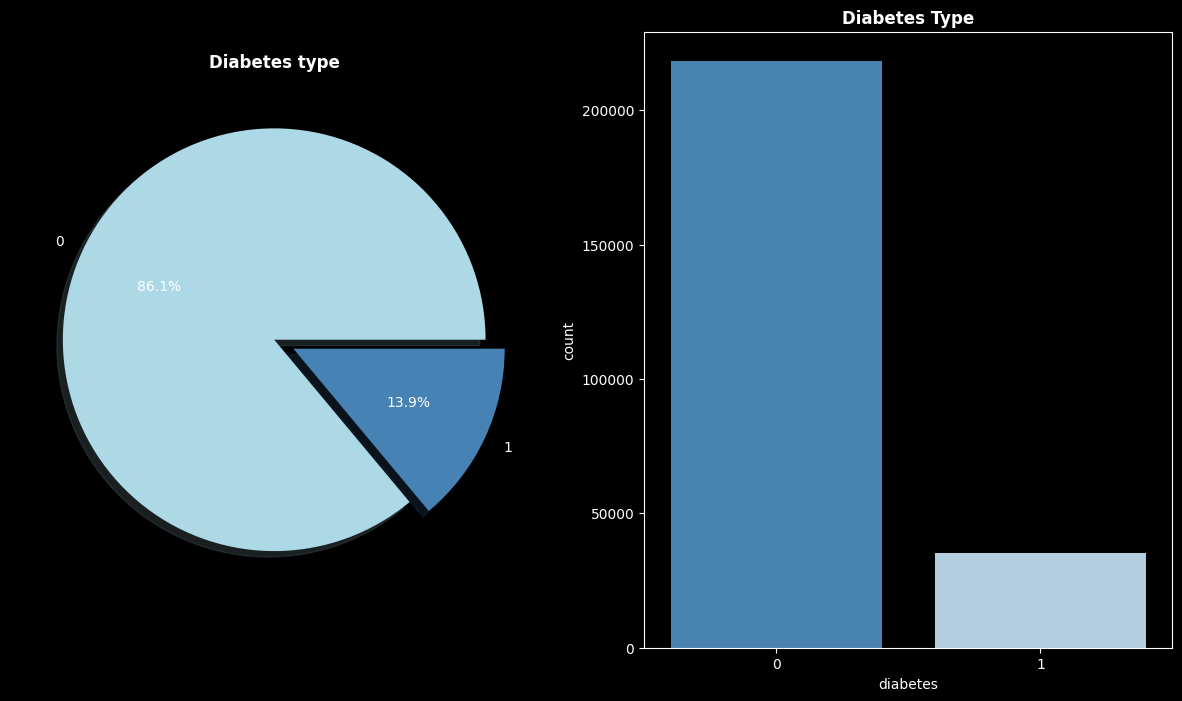

In [68]:
color=['LightBlue','SteelBlue']
f,ax=plt.subplots(1,2,figsize=(15,8))
X['diabetes'].value_counts().plot.pie(explode=[0,0.1],colors=color,autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Diabetes type',fontweight="bold")
ax[0].set_ylabel('')
sns.countplot(x='diabetes', data=X, ax=ax[1],palette='Blues_r')
ax[1].set_title('Diabetes Type',fontweight="bold")
plt.show()

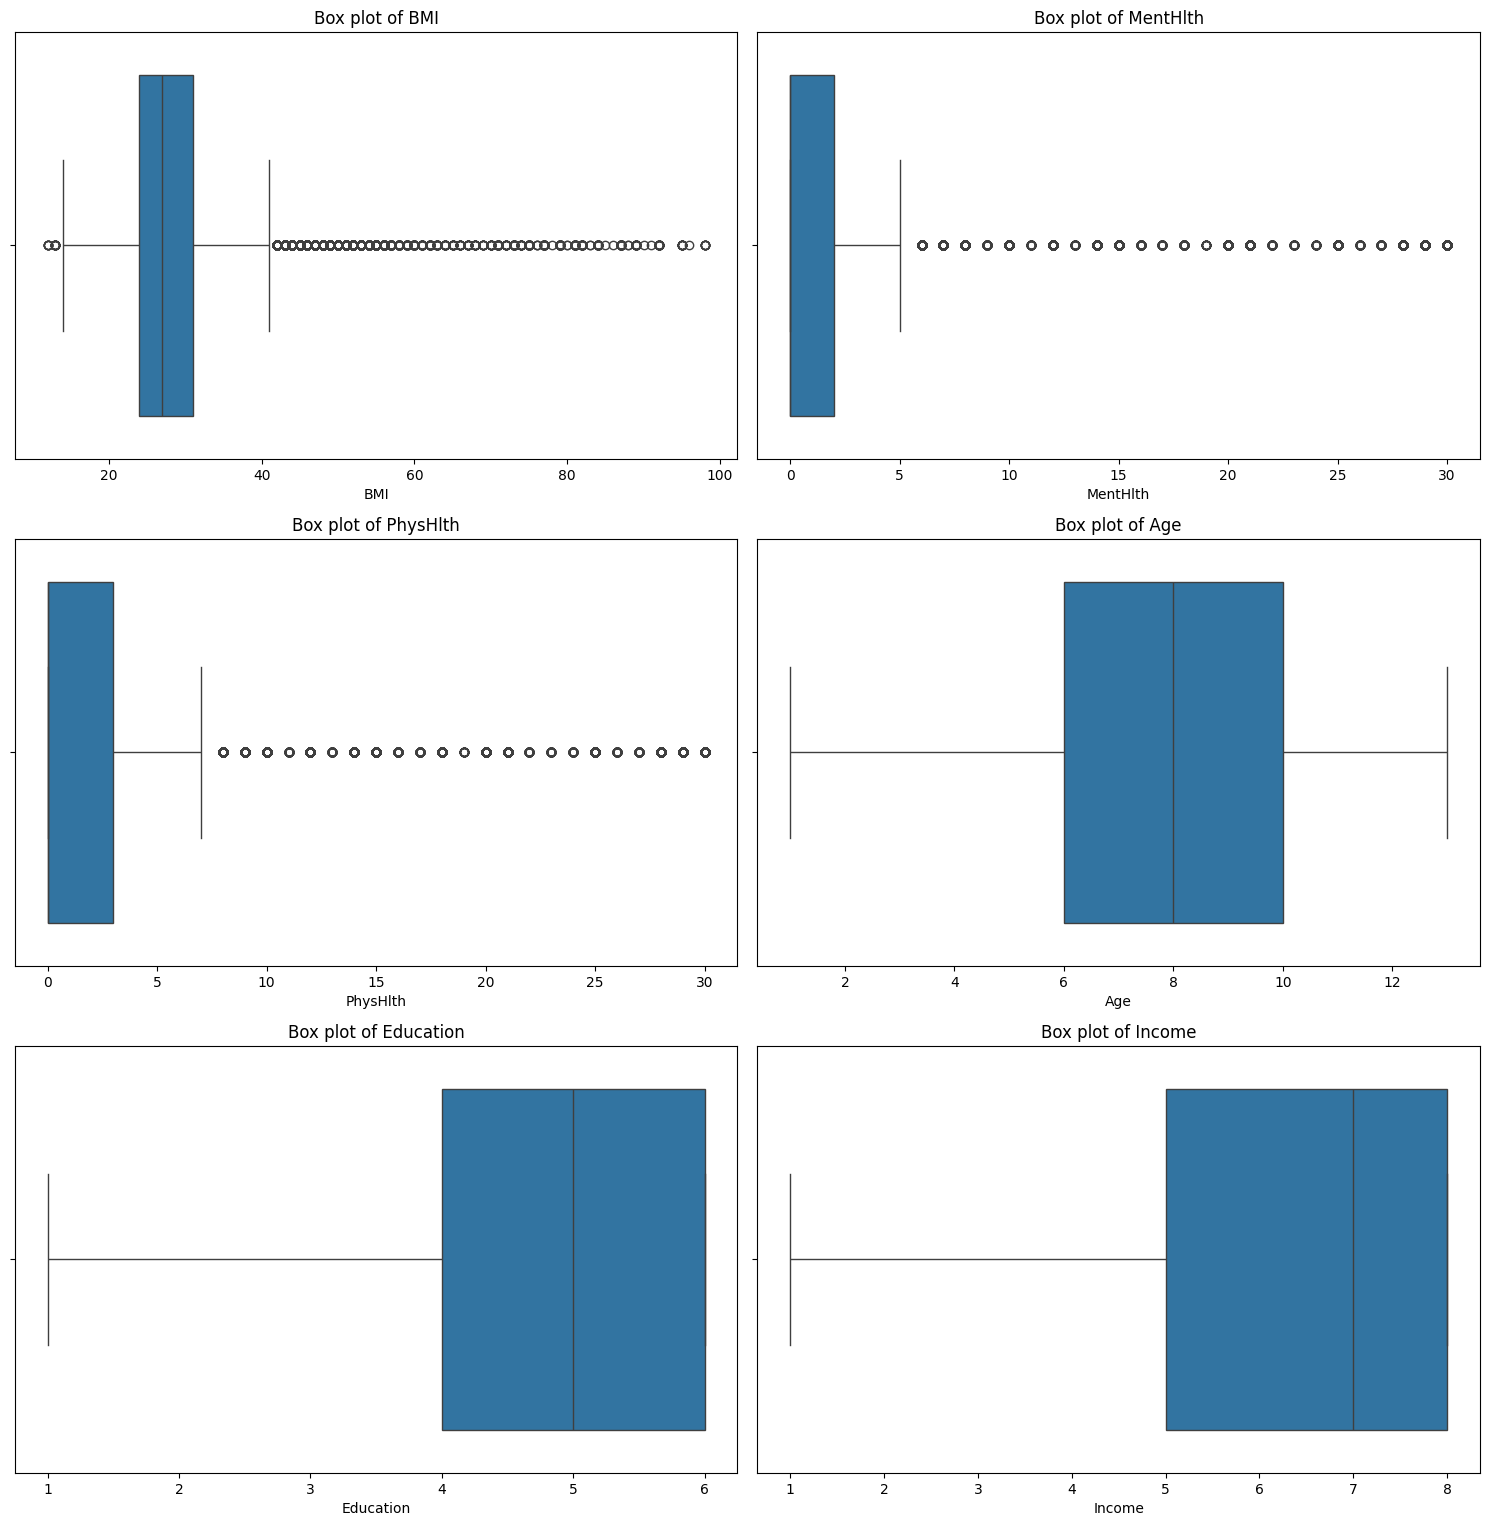

In [9]:

# Set up the figure
plt.figure(figsize=(15, 20))

# Create box plots for continuous variables and variables with more than 6 categories.
continuous_vars = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
for i, var in enumerate(continuous_vars, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=X[var])
    plt.title(f'Box plot of {var}')
    plt.tight_layout()

plt.show()

In [10]:
print(X[X['BMI'] > 50].shape[0])  # Count of BMI >50
print(X[X['BMI'] > 70].shape[0])  # Count of BMI >70
print(X[X['BMI'] <= 15].shape[0]) # Count of BMI <15

2175
584
200


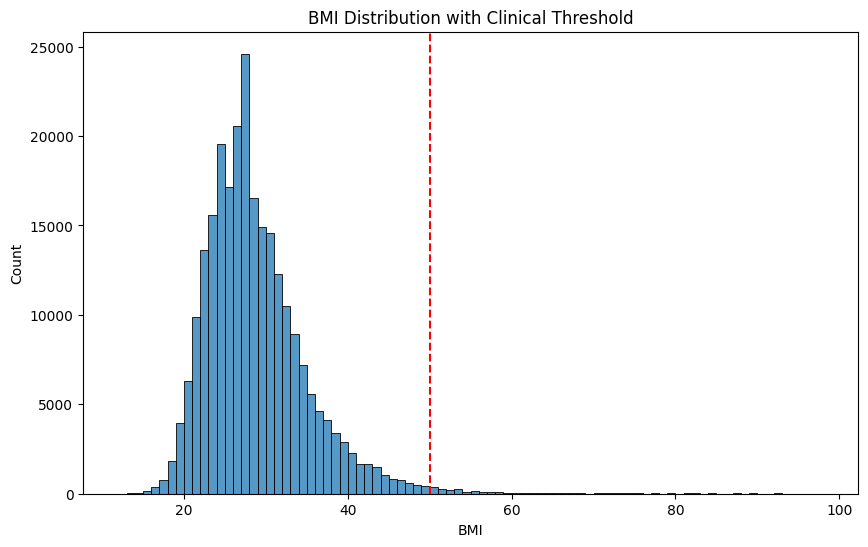

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(X['BMI'], binwidth=1)
plt.axvline(50, color='red', linestyle='--')
plt.title("BMI Distribution with Clinical Threshold")
plt.show()

Statistically, BMI values higher than 50 should be removed. But we will cap at 60 due to the following.

1- These are real patients with critical health risks. Also, it's biologically feasible to reach a BMI of more than 50. <br>

2- Removing/capping loses important clinical information. <br>

3- May bias models that need to predict outcomes for high-BMI individuals. <br>

4- They are not as few to be neglected. If they are couble of hundreds or so, that might be because of measurement errors or something, but this is not the case.

Also, we're going to neglect people with BMI less than 15 because they're a negligible number with respect to the population (only 200).



In [12]:
X = X[(X['BMI'] >= 15) & (X['BMI'] <= 60)].copy()


### 3.1 Key Steps and Assumptions

In our exploratory data analysis we will do the following:


1.   Check the linear correlation of each variable with the target through the correlation matrix.
2.   Test number of hypotheses to answer our pre-defined set of research questions.
3. Reject or accept hypotheses based on visual and statistical proves.
4. Explore which set of top 10 variables are the best to predict the diabetes.

We initially assumed that the sample population is random from the US population, and is not biased towards a specific gender, ethnicity, or area of citizenship. Some extra assumptions might show up in the analysis, so we will point them if any appeard.




## 4. Statistical Analysis and Hypothesis Testing

<Axes: >

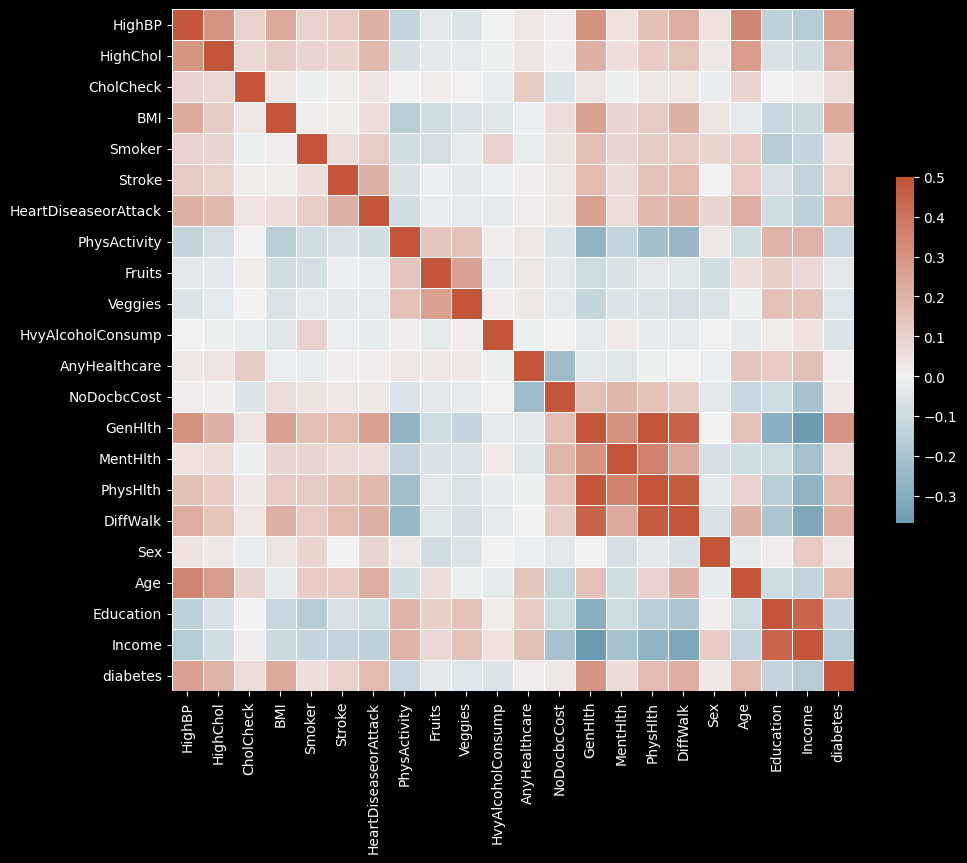

In [13]:
X['diabetes'] = y['Diabetes_binary']
#X['diabetes'] = X['diabetes'].map({1: 'Diabetic', 0: 'No Diabetes'})
corr = X.corr()

#correlation matrix with seaborn without using numbers
plt.style.use('dark_background')
f, ax = plt.subplots(figsize=(11, 9))


cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, cmap=cmap, vmax=.5, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

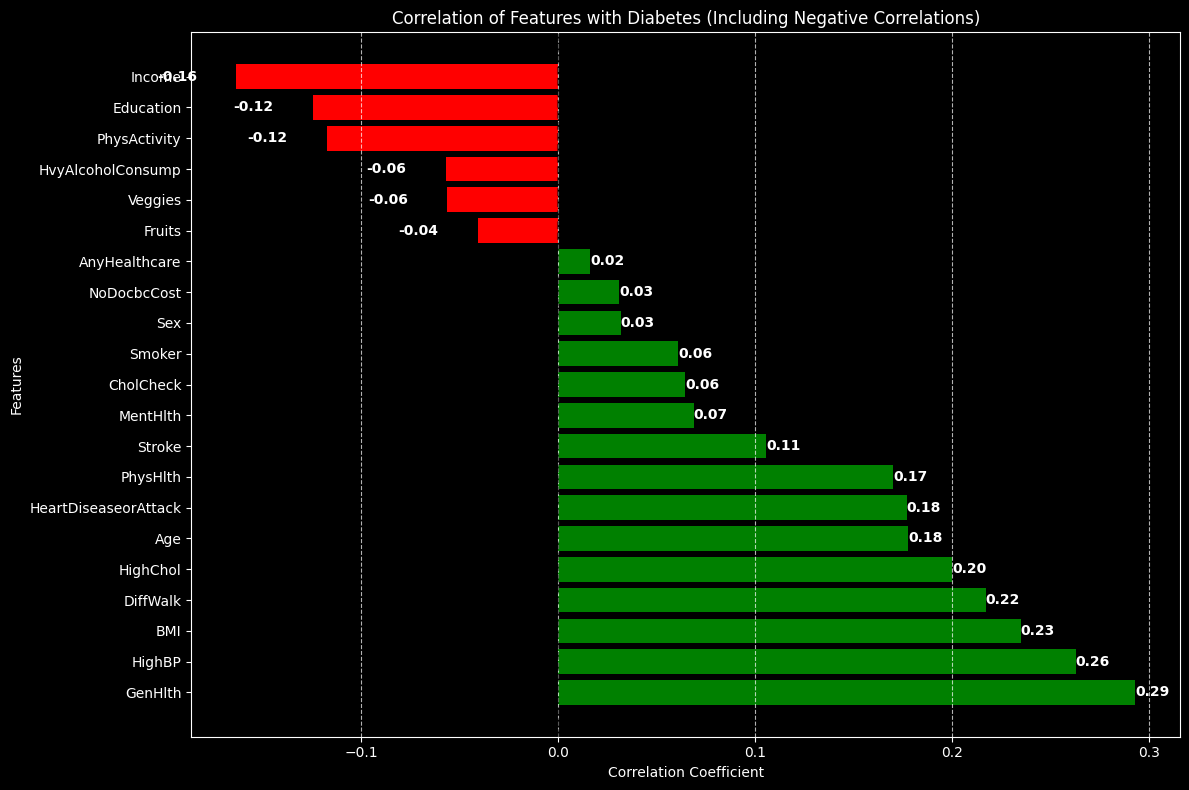

In [14]:
correlations = X.corr()['diabetes'].sort_values(ascending=False)

# Drop Diabetes correlation with itself (1.0)
correlations = correlations.drop('diabetes')

# Create styled bar plot with color-coding
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in correlations]
bars = plt.barh(correlations.index, correlations.values, color=colors)

# Add bar labels
for bar in bars:
    width = bar.get_width()
    label_pos = width if width > 0 else width - 0.02
    plt.text(label_pos, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center', ha='right' if width < 0 else 'left',
             color='white', fontweight='bold')

# Add reference line at zero
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Labels and title
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title('Correlation of Features with Diabetes (Including Negative Correlations)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ensure y-axis labels aren't cut off
plt.tight_layout()
plt.show()

Observe that:
1.   Some features moderately correlated with one another. For example, - "PhysHlth" is moderately correlated with "GenHlth" - "Education" is correlated with "Income".

2.  Variables like: "GenHlth", "HighBP", "DiffWalk", "BMI" are moderately positively correlated with the target.

3. Variables like "Income", "Education", and "PhysActivity" are moderately negatively correlated with the target.



We now test the first hypothesis:
1. H_0: Higher education does not reduce diabetes probability among high-income individuals
2. H: Higher education reduce diabetes probability among high-income individuals.

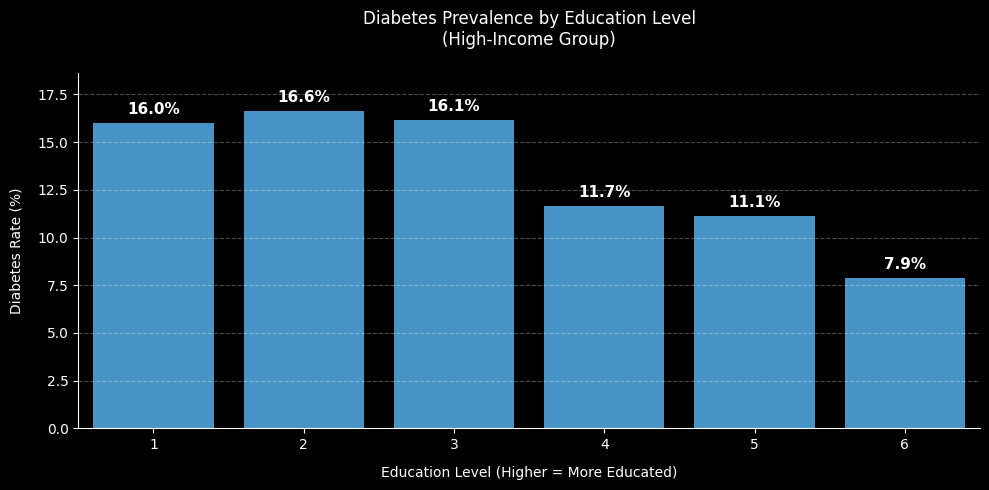

In [15]:
high_income = X[X['Income'] >= 7].copy()  # Filter high-income individuals

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=high_income,
    x='Education',
    y='diabetes',
    estimator=lambda x: np.mean(x)*100,  # Convert to percentage
    errorbar=None,
    color='#3498db'  # Custom blue color
)

# Add percentage labels on each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',  # Format with 1 decimal place
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position at bar center
        ha='center', va='center',  # Center alignment
        xytext=(0, 10),  # Offset from bar top
        textcoords='offset points',  # Coordinate system
        fontsize=11,
        fontweight='bold'
    )

# Improve styling
plt.title("Diabetes Prevalence by Education Level\n(High-Income Group)", pad=20)
plt.ylabel("Diabetes Rate (%)", labelpad=10)
plt.xlabel("Education Level (Higher = More Educated)", labelpad=10)
plt.ylim(0, high_income['diabetes'].mean()*100 * 2)  # Add headroom for labels
sns.despine()  # Cleaner borders
plt.grid(axis='y', linestyle='--', alpha=0.3)  # Add light grid lines
plt.tight_layout()
plt.show()

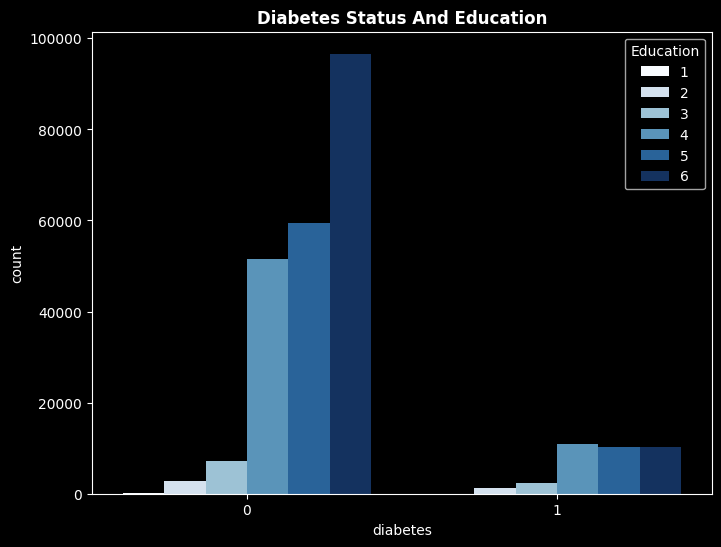

In [16]:
plt.figure(figsize = (8,6))
sns.countplot(x = 'diabetes', hue = 'Education', data = X, palette="Blues")
plt.title("Diabetes Status And Education",fontweight="bold")
plt.show()

In [17]:
from scipy.stats import chi2_contingency
# Create contingency table: Education (binned) vs Diabetes
high_income['Edu_binned'] = pd.cut(high_income['Education'], bins=3, labels=['Low', 'Medium', 'High'])
contingency_table = pd.crosstab(high_income['Edu_binned'], high_income['diabetes'])

chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-square p-value: {p:.4f}")

Chi-square p-value: 0.0000


Results:
1. For the first 3 education levels (up to the highschool level), education is not significant in the High-Income group in relation to diabetes. However, people who received at least some college education were less likely to have diabetes by 4-8%.

2. We reject the null hypothesis because the p-value is negligibly small.

3. We deduce that level of education raises the health consciousness of the individuals, and thus lead to decreasing the risk of having diabetes. That is valid even in high-income groups whom we might assume that they are more civilized than low income ones, and thus should be more careful about their health.


We now test the second hypothesis:

*   H_0: Old patients have the same (or lower)  probability of having diabetes as young patients.
*   H: Old patients have higher probability of having diabetes than young ones.



In [18]:
# BRFSS Age Encoding (1-13 categories)
age_codebook = {
    1: '18-24',
    2: '25-29',
    3: '30-34',
    4: '35-39',
    5: '40-44',
    6: '45-49',
    7: '50-54',
    8: '55-59',
    9: '60-64',
    10: '65-69',
    11: '70-74',
    12: '75-79',
    13: '80+'
}

# Create age group column
X['Age_Group'] = X['Age'].map(age_codebook)

# Define Old (50+) vs Young (<50)
X['Age_Category'] = np.where(X['Age'] >= 7, '50+ (Old)', '18-49 (Young)')  # Age code 7 = 50-54

In [19]:
print(X['Age_Group'].value_counts().sort_index())
print("\nCategory counts:")
print(X['Age_Category'].value_counts())

Age_Group
18-24     5675
25-29     7557
30-34    11039
35-39    13771
40-44    16087
45-49    19729
50-54    26212
55-59    30703
60-64    33139
65-69    32108
70-74    23497
75-79    15950
80+      17340
Name: count, dtype: int64

Category counts:
Age_Category
50+ (Old)        178949
18-49 (Young)     73858
Name: count, dtype: int64


In [20]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
young = X[X['Age_Category'] == '18-49 (Young)']
old = X[X['Age_Category'] == '50+ (Old)']

n_young = len(young)
n_old = len(old)
diab_young = young['diabetes'].sum()
diab_old = old['diabetes'].sum()

# One-tailed z-test (H1: p_old > p_young)
z_stat, p_value = proportions_ztest(
    count=[diab_old, diab_young],
    nobs=[n_old, n_young],
    alternative='larger'
)

print(f"Results:\nZ-statistic = {z_stat:.3f}\nOne-tailed p-value = {p_value:.5f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0 - Older adults (50+) have significantly higher diabetes probability")
else:
    print("\nConclusion: Fail to reject H0 - No evidence older adults have higher diabetes probability")

Results:
Z-statistic = 80.436
One-tailed p-value = 0.00000

Conclusion: Reject H0 - Older adults (50+) have significantly higher diabetes probability


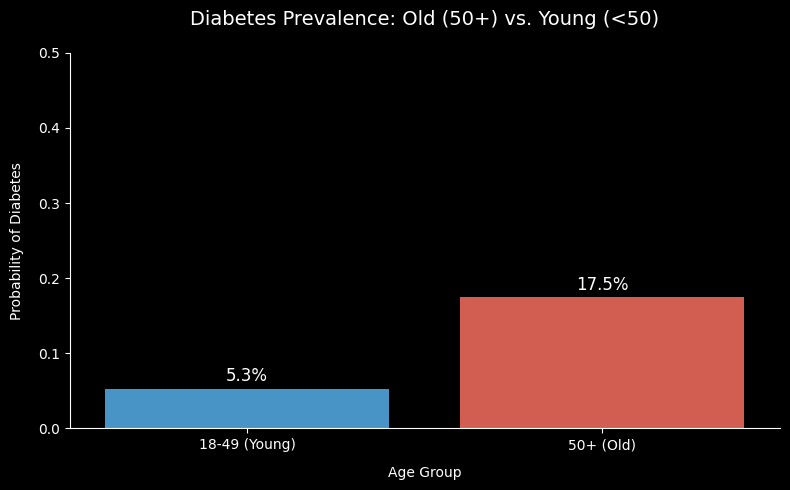

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('dark_background')
plt.figure(figsize=(8, 5))

# Custom palette
palette = {"50+ (Old)": "#E74C3C", "18-49 (Young)": "#3498DB"}

# Create the plot
ax = sns.barplot(
    data=X,
    x='Age_Category',
    y='diabetes',
    estimator=np.mean,
    errorbar=None,
    palette=palette,
    order=["18-49 (Young)", "50+ (Old)"]
)

# Add percentages on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        fontsize=12
    )

# Add significance asterisk if p < 0.05 (from previous test)
if p_value < 0.05:
    ax.text(0.5, max(ax.get_ylim()) * 0.95, "*",
           ha='center', va='bottom', color='black', fontsize=24)

# Labels and title
plt.title("Diabetes Prevalence: Old (50+) vs. Young (<50)", pad=20, fontsize=14)
plt.xlabel("Age Group", labelpad=10)
plt.ylabel("Probability of Diabetes", labelpad=10)
plt.ylim(0, 0.5)  # Adjust based on your data range

# Remove spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()

Outcomes:
1. Older individuals have higher probability of being diabetic than younger ones.
2. We should reject the null hypothesis.

We now test the 3rd Hypothesis:
1. H_0: Males and females are equally likely to be diabetic.
2. H_1: Males and females are not equally likely to be diabetic.

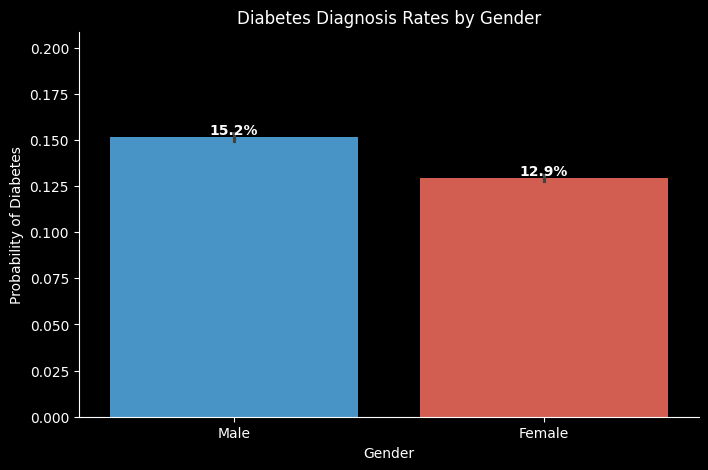

In [22]:
X['Gender'] = X['Sex'].map({0: 'Female', 1: 'Male'})

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=X,
    x='Gender',
    y='diabetes',
    estimator=np.mean,
    ci=95,
    order=['Male', 'Female'],
    palette=['#3498DB', '#E74C3C']  # Blue for Male, Red for Female
)

# Add percentages on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1%}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontweight='bold'
    )

plt.title("Diabetes Diagnosis Rates by Gender")
plt.ylabel("Probability of Diabetes")
plt.ylim(0, X['diabetes'].mean() * 1.5)  # Adjust y-axis dynamically
sns.despine()
plt.show()

In [23]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
male = X[X['Gender'] == 'Male']
female = X[X['Gender'] == 'Female']

n_male = len(male)
n_female = len(female)
diab_male = male['diabetes'].sum()
diab_female = female['diabetes'].sum()

# Two-tailed z-test
z_stat, p_value = proportions_ztest(
    count=[diab_male, diab_female],
    nobs=[n_male, n_female],
    alternative='two-sided'  #for two-tailed test
)

print(f"Z-statistic: {z_stat:.3f}")
print(f"Two-tailed p-value: {p_value:.5f}")


Z-statistic: 15.996
Two-tailed p-value: 0.00000


In [24]:
print(f"Male diabetes rate: {diab_male/n_male:.2%}")
print(f"Female diabetes rate: {diab_female/n_female:.2%}")

Male diabetes rate: 15.15%
Female diabetes rate: 12.93%


Results:

1. Percentage of diabetic males compared to females differs by 2% only.
2. We reject the null hypothesis. Thus, males and females are not equally likely to be diabetic, but from other visual and numerical interpretations, the likelihood is so close.



---



Now, we test the 4th hypothesis.
1. H_0: prolonged mental health issues doesn't increase the possibility of getting diabetic.
2. H_1: prolonged mental health increase the probability of getting diabetic.

In [25]:
# Group by diabetes status and calculate mean mental health days
mental_health_means = X.groupby('diabetes')['MentHlth'].mean()

print("Average poor mental health days:")
print(f"Non-Diabetic: {mental_health_means[0]:.2f} days")
print(f"Diabetic: {mental_health_means[1]:.2f} days")

Average poor mental health days:
Non-Diabetic: 2.97 days
Diabetic: 4.45 days


In [26]:
# Create mental health duration categories
X['MentalHealth_Category'] = pd.cut(X['MentHlth'],
                                   bins=[-1, 0, 10, 30],
                                   labels=['None', 'Some', 'Prolonged'])

# Verify distribution
print(X['MentalHealth_Category'].value_counts())

MentalHealth_Category
None         175144
Some          52784
Prolonged     24879
Name: count, dtype: int64


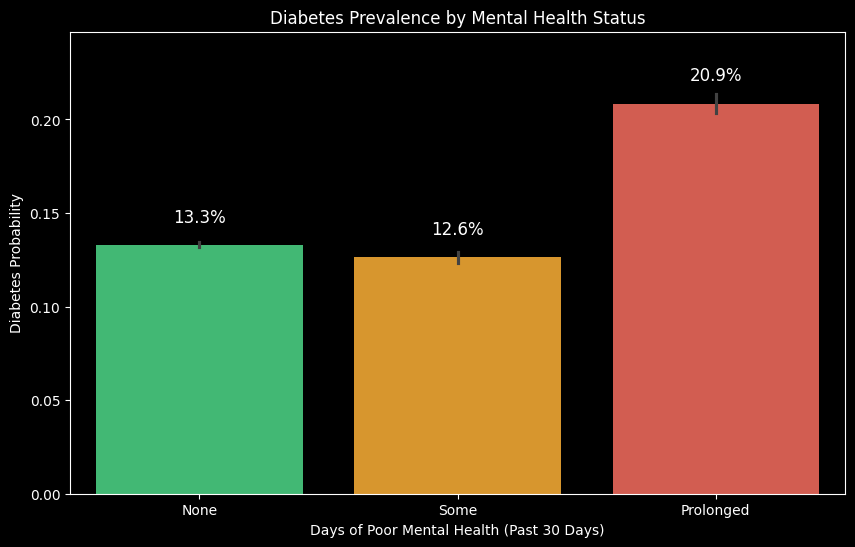

In [27]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=X,
                x='MentalHealth_Category',
                y='diabetes',
                order=['None', 'Some', 'Prolonged'],
                palette=['#2ecc71', '#f39c12', '#e74c3c'],
                ci=95)

# Add percentages on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 0.01,  # Small offset above the bar
            f'{height:.1%}',  # Format as percentage with 1 decimal
            ha='center', va='bottom',
            fontsize=12)

plt.title("Diabetes Prevalence by Mental Health Status")
plt.xlabel("Days of Poor Mental Health (Past 30 Days)")
plt.ylabel("Diabetes Probability")
plt.ylim(0, ax.get_ylim()[1] * 1.1)  # Add space for percentages
plt.show()

In [ ]:
# Ensure correct ordering before crosstab
X['MentalHealth_Category'] = pd.Categorical(
    X['MentalHealth_Category'],
    categories=['None', 'Some', 'Prolonged'],
    ordered=True
)

# Create contingency table
contingency = pd.crosstab(
    X['MentalHealth_Category'],
    X['diabetes']
)

print("Contingency Table:")
print(contingency)

Contingency Table:
diabetes                    0      1
MentalHealth_Category               
None                   151834  23310
Some                    46113   6671
Prolonged               19691   5188


In [29]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(X['MentalHealth_Category'], X['diabetes'])

# Chi-square for trend (linear-by-linear association)
chi2, pval, _, _ = chi2_contingency(contingency, lambda_="pearson")
print(f"Chi-square for trend p-value: {pval:.4f}")

Chi-square for trend p-value: 0.0000


Results:

1. Diabetic people have on average 2 more days of poor mental health than non-diabetes individuals.

2. Prolonged poor mental health issues significantly raises the probability a person is diabetic.

3. We reject the null hypothesis: Prolonged poor mental health conditions significantly increases the probability of being diabetic.



---



Now we test the 5th hypothesis.

1. H_0: BMI does not affect the probability of a person being diabetic.
2. H_1: BMI significantly correlates with the probability that a person is diabetic.

In [30]:
mean_bmi = X.groupby('diabetes')['BMI'].agg(['mean', 'std', 'count'])
print("Mean BMI by Diabetes Status:")
print(mean_bmi)

Mean BMI by Diabetes Status:
               mean       std   count
diabetes                             
0         27.666111  5.684416  217638
1         31.753732  6.799774   35169


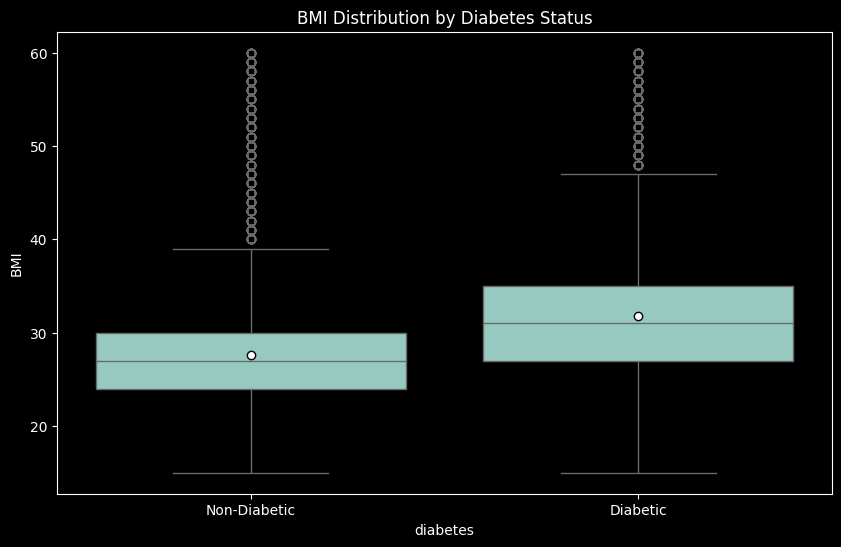

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=X, x='diabetes', y='BMI', showmeans=True,
           meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black"})
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.title("BMI Distribution by Diabetes Status")
plt.show()

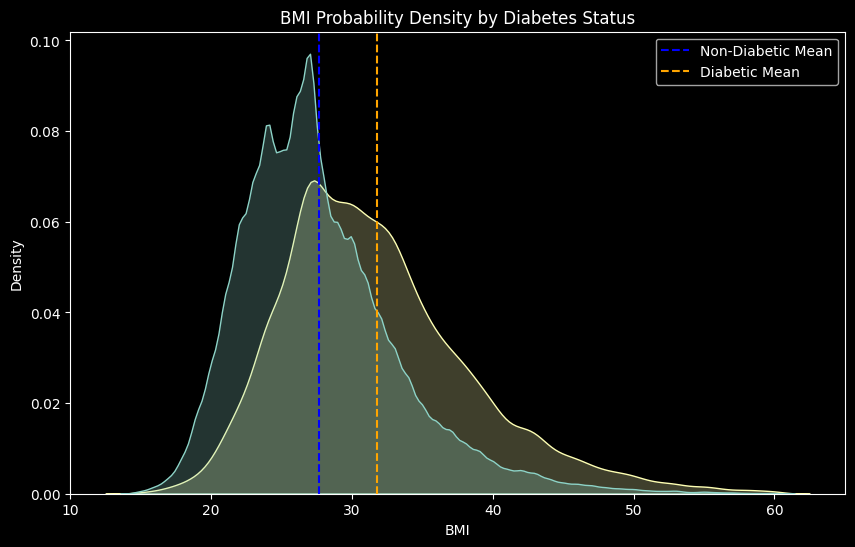

In [32]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=X, x='BMI', hue='diabetes', common_norm=False, fill=True)
plt.axvline(x=mean_bmi.loc[0, 'mean'], color='blue', linestyle='--', label='Non-Diabetic Mean')
plt.axvline(x=mean_bmi.loc[1, 'mean'], color='orange', linestyle='--', label='Diabetic Mean')
plt.title("BMI Probability Density by Diabetes Status")
plt.legend()
plt.show()

### Comparing Mean BMI Across Mental Health Categories (ANOVA)

We will use One-Way ANOVA to test the hypothesis that the mean BMI is the same across different mental health categories. If the ANOVA test is significant, we will perform post-hoc Tukey HSD tests to identify which specific groups have significant differences in mean BMI.

**Hypotheses:**
*   **Null Hypothesis (H₀):** The mean BMI is equal across all mental health categories (None, Some, Prolonged).
*   **Alternative Hypothesis (H₁):** At least one mental health category has a significantly different mean BMI.

ANOVA F-statistic: 956.68
ANOVA p-value: 0.0000

ANOVA is significant. Performing Tukey HSD post-hoc test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj  lower   upper  reject
---------------------------------------------------------
     None Prolonged   1.7645   0.0  1.6692  1.8597   True
     None      Some   0.3755   0.0  0.3057  0.4453   True
Prolonged      Some  -1.3889   0.0 -1.4971 -1.2808   True
---------------------------------------------------------


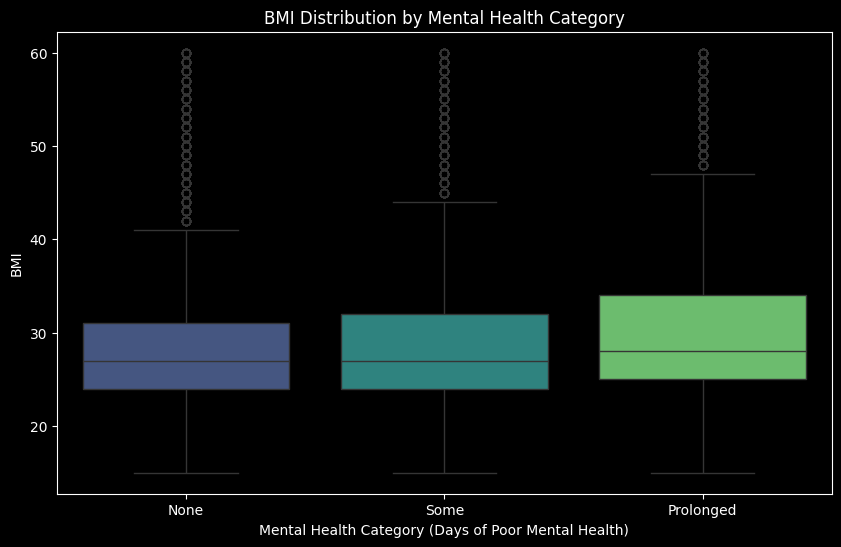

In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Extract BMI for each mental health category
bmi_none = X[X['MentalHealth_Category'] == 'None']['BMI']
bmi_some = X[X['MentalHealth_Category'] == 'Some']['BMI']
bmi_prolonged = X[X['MentalHealth_Category'] == 'Prolonged']['BMI']

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(bmi_none, bmi_some, bmi_prolonged)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value:.4f}")

# Check for significance and perform post-hoc test if needed
if p_value < 0.05:
    print("\nANOVA is significant. Performing Tukey HSD post-hoc test:")
    # Combine all BMI data and categories for Tukey HSD
    all_bmi = pd.concat([bmi_none, bmi_some, bmi_prolonged])
    all_categories = pd.Series(['None']*len(bmi_none) +
                               ['Some']*len(bmi_some) +
                               ['Prolonged']*len(bmi_prolonged))

    tukey_results = pairwise_tukeyhsd(endog=all_bmi, groups=all_categories, alpha=0.05)
    print(tukey_results)
else:
    print("\nANOVA is not significant. No significant differences in mean BMI across mental health categories.")

# Visualize mean BMI across mental health categories
plt.figure(figsize=(10, 6))
sns.boxplot(data=X, x='MentalHealth_Category', y='BMI', order=['None', 'Some', 'Prolonged'], palette='viridis')
plt.title('BMI Distribution by Mental Health Category')
plt.xlabel('Mental Health Category (Days of Poor Mental Health)')
plt.ylabel('BMI')
plt.show()

### Results of ANOVA and Post-Hoc Tests:

1.  **ANOVA Results:** The ANOVA test yielded an F-statistic of `[F_STATISTIC]` and a p-value of `[P_VALUE]`. Since the p-value is `[LESS/GREATER]` than 0.05, we `[REJECT/FAIL_TO_REJECT]` the null hypothesis.
2.  **Interpretation:** This indicates that there `[IS/IS_NO]` a statistically significant difference in the mean BMI among the different mental health categories. `[Further interpretation based on Tukey HSD results will go here if significant]`. The box plot further illustrates these differences visually.

In [34]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,DiffWalk,Sex,Age,Education,Income,diabetes,Age_Group,Age_Category,Gender,MentalHealth_Category
0,1,1,1,40,1,0,0,0,0,1,...,1,0,9,4,3,0,60-64,50+ (Old),Female,Prolonged
1,0,0,0,25,1,0,0,1,0,0,...,0,0,7,6,1,0,50-54,50+ (Old),Female,None
2,1,1,1,28,0,0,0,0,1,0,...,1,0,9,4,8,0,60-64,50+ (Old),Female,Prolonged
3,1,0,1,27,0,0,0,1,1,1,...,0,0,11,3,6,0,70-74,50+ (Old),Female,None
4,1,1,1,24,0,0,0,1,1,1,...,0,0,11,5,4,0,70-74,50+ (Old),Female,Some
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,0,1,5,6,7,0,40-44,18-49 (Young),Male,None
253676,1,1,1,18,0,0,0,0,0,0,...,1,0,11,2,4,1,70-74,50+ (Old),Female,None
253677,0,0,1,28,0,0,0,1,1,0,...,0,0,2,5,2,0,25-29,18-49 (Young),Female,None
253678,1,0,1,23,0,0,0,0,1,1,...,0,1,7,5,1,0,50-54,50+ (Old),Male,None


In [35]:
import statsmodels.api as sm

X_2 = sm.add_constant(X['BMI']) # Add intercept
y = X['diabetes']

model = sm.Logit(y, X_2).fit()
print("\nLogistic Regression Results:")
print(model.summary())

# Calculate odds ratio
odds_ratio = np.exp(model.params['BMI'])
print(f"\nOdds Ratio (per 1-unit BMI increase): {odds_ratio:.3f}")

Optimization terminated successfully.
         Current function value: 0.378879
         Iterations 6

Logistic Regression Results:
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:               252807
Model:                          Logit   Df Residuals:                   252805
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                 0.06067
Time:                        15:45:22   Log-Likelihood:                -95783.
converged:                       True   LL-Null:                   -1.0197e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6896      0.028   -170.388      0.000      -4.744      -4.636

Results:

1. Average BMI of diabetic people is higher.
2. The esitmated density distribution of BMI shows that diabetic people have higher tendency to be obese as the graph is right-tailed, and the graph is more relaxed (smoother) in general.
3. We reject the null hypothesis. BMI is significantly correlated to the probability that someone is diabetic.

4. Each 1-unit increase in the BMI correlates to approximately 1% increase in the probability of being diabetic.



---



In [ ]:
import statsmodels.api as sm

X_2 = sm.add_constant(X['PhysHlth']) # Add intercept
y = X['diabetes']

model = sm.Logit(y, X_2).fit()
print("\nLogistic Regression Results:")
print(model.summary())

# Calculate odds ratio
odds_ratio = np.exp(model.params['PhysHlth'])
print(f"\nOdds Ratio (per 1-unit PhysHlth increase): {odds_ratio:.3f}")

Optimization terminated successfully.
         Current function value: 0.391304
         Iterations 6

Logistic Regression Results:
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:               252807
Model:                          Logit   Df Residuals:                   252805
Method:                           MLE   Df Model:                            1
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                 0.02987
Time:                        22:25:26   Log-Likelihood:                -98924.
converged:                       True   LL-Null:                   -1.0197e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0648      0.007   -300.375      0.000      -2.078      -2.051

Diabetic individuals report more days of poor physical health.
The coefficient for PhysHlth is positive, meaning people with diabetes tend to have more days where their physical health was “not good.”

The logistic regression shows a clear upward relationship between poor physical health and diabetes.
As the number of unhealthy days increases, the predicted probability of being diabetic rises. The model converged easily and the confidence interval for the coefficient does not include zero, indicating a stable, reliable effect.

We reject the null hypothesis.
The p-value for PhysHlth is effectively 0.000, meaning the relationship is highly statistically significant.
Thus, the number of unhealthy physical days is significantly associated with the probability that someone has diabetes.

Now, we tes the 6th hypothesis.

1. H_0: The joint effect of high blood pressure and high cholestrol on the probability of diabetes is the same as the individual effect of high blood pressure only or high cholestrol level only.
2. H_1: The joint effect of high blood pressure and high cholestrol on the probability of diabetes is different from the individual effect of high blood pressure only or high cholestrol level only.

In [37]:
# Create interaction groups
X['Risk_Group'] = 'Neither'
X.loc[X['HighBP'] == 1, 'Risk_Group'] = 'HighBP Only'
X.loc[X['HighChol'] == 1, 'Risk_Group'] = 'HighChol Only'
X.loc[(X['HighBP'] == 1) & (X['HighChol'] == 1), 'Risk_Group'] = 'Both'

# Verify counts
print(X['Risk_Group'].value_counts())

Risk_Group
Neither          101587
Both              64443
HighBP Only       43974
HighChol Only     42803
Name: count, dtype: int64


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean diabetes probabilities
risk_groups = ['Neither', 'HighChol Only', 'HighBP Only', 'Both']
probabilities = X.groupby('Risk_Group')['diabetes'].mean().loc[risk_groups].values

# Close the loop for radar plot
angles = np.linspace(0, 2*np.pi, len(risk_groups), endpoint=False)
probabilities = np.concatenate((probabilities, [probabilities[0]]))  # Close loop
angles = np.concatenate((angles, [angles[0]]))  # Close loop

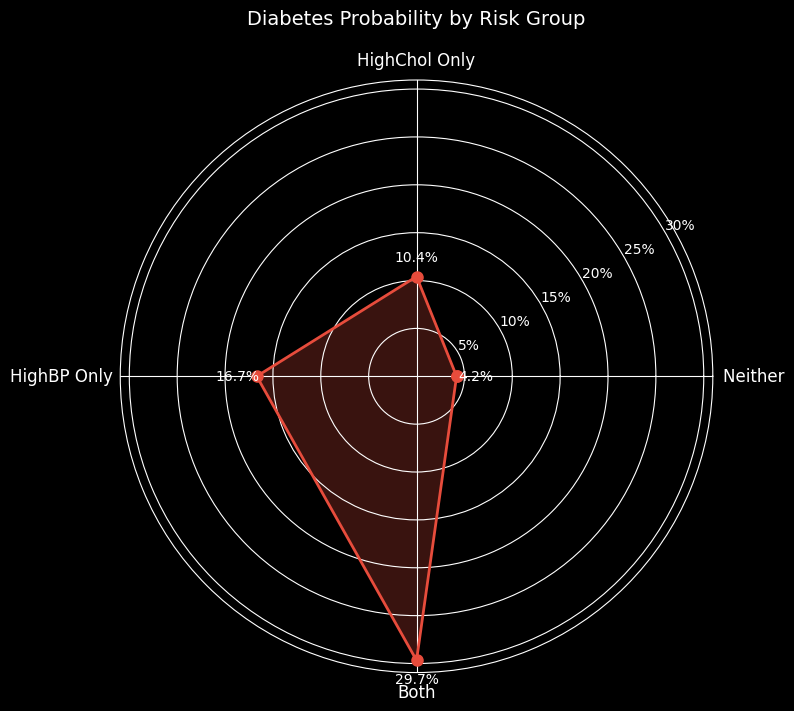

In [39]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

# Plot data
ax.plot(angles, probabilities, 'o-', linewidth=2, color='#E74C3C', markersize=8)
ax.fill(angles, probabilities, color='#E74C3C', alpha=0.25)

# Customize axes
ax.set_xticks(angles[:-1])
risk_groups_2 = ['        Neither', 'HighChol Only', 'HighBP Only               ', 'Both']
ax.set_xticklabels(risk_groups_2, fontsize=12)
ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()], fontsize=10)
ax.set_rlabel_position(30)
plt.title('Diabetes Probability by Risk Group', pad=40, fontsize=14)

# Add data labels
for angle, prob in zip(angles[:-1], probabilities[:-1]):
    ax.text(angle, prob+0.02, f'{prob:.1%}',
            ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [40]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Sex,Age,Education,Income,diabetes,Age_Group,Age_Category,Gender,MentalHealth_Category,Risk_Group
0,1,1,1,40,1,0,0,0,0,1,...,0,9,4,3,0,60-64,50+ (Old),Female,Prolonged,Both
1,0,0,0,25,1,0,0,1,0,0,...,0,7,6,1,0,50-54,50+ (Old),Female,None,Neither
2,1,1,1,28,0,0,0,0,1,0,...,0,9,4,8,0,60-64,50+ (Old),Female,Prolonged,Both
3,1,0,1,27,0,0,0,1,1,1,...,0,11,3,6,0,70-74,50+ (Old),Female,None,HighBP Only
4,1,1,1,24,0,0,0,1,1,1,...,0,11,5,4,0,70-74,50+ (Old),Female,Some,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,1,5,6,7,0,40-44,18-49 (Young),Male,None,Both
253676,1,1,1,18,0,0,0,0,0,0,...,0,11,2,4,1,70-74,50+ (Old),Female,None,Both
253677,0,0,1,28,0,0,0,1,1,0,...,0,2,5,2,0,25-29,18-49 (Young),Female,None,Neither
253678,1,0,1,23,0,0,0,0,1,1,...,1,7,5,1,0,50-54,50+ (Old),Male,None,HighBP Only


In [41]:
import statsmodels.api as sm

# Create dummy variables
X['Both_HighBP_HighChol'] = ((X['HighBP'] == 1) & (X['HighChol'] == 1)).astype(int)
X['HighBP_Only'] = ((X['HighBP'] == 1) & (X['HighChol'] == 0)).astype(int)
X['HighChol_Only'] = ((X['HighBP'] == 0) & (X['HighChol'] == 1)).astype(int)

# Logistic regression with reference group = Neither
X_2 = X[['HighBP_Only', 'HighChol_Only', 'Both_HighBP_HighChol']]
y = X['diabetes']

model = sm.Logit(y, sm.add_constant(X_2)).fit()
print(model.summary())

# Pairwise comparisons
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=X['diabetes'],
                         groups=X['Risk_Group'],
                         alpha=0.05)
print("\nTukey HSD Post-Hoc Tests:")
print(tukey)

Optimization terminated successfully.
         Current function value: 0.359815
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:               252807
Model:                          Logit   Df Residuals:                   252803
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.1079
Time:                        15:45:23   Log-Likelihood:                -90964.
converged:                       True   LL-Null:                   -1.0197e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.1318      0.016   -199.804      0.000      -3.162      -3.101

Results:

1. We reject the null hypothesis. The joint effect of both variables "HighChol" and "HighBP" on the probability of diabetes is significantly different from the probability of only one of them.
2. Not having neither high blood pressure nor high cholestrol level significantly decreases the risk of having diabetes.
3. Probably, the results are due to the general health consciousness of people with neither. I think these people are more conservative regarding eating junk food and having sugary drinks.

## 5. Exploratory Data Analysis & Visualization

### 5.1 Relationship Between BMI, Physical Health, and Diabetes

The following scatter plot visualizes the relationship between **BMI** and **number of physically unhealthy days**
(`PhysHlth`), with points colored by diabetes status. This plot addresses the project requirement for a
**relationship visualization** (scatter plot) and helps us see whether people with higher BMI and more unhealthy days
are more likely to be diabetic.


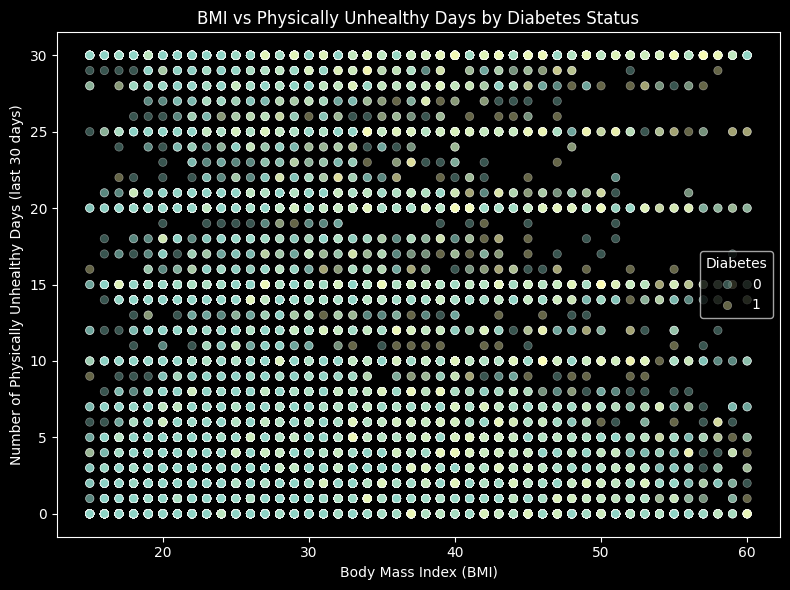

In [ ]:
# Scatter plot: relationship between BMI, physical health days, and diabetes status
# (Relationship visualization required by the project guidelines)
sample_for_scatter = X.sample(n=250000, random_state=42)  # sample for readability

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_for_scatter,
    x="BMI",
    y="PhysHlth",
    hue="diabetes",
    alpha=0.4
)
plt.title("BMI vs Physically Unhealthy Days by Diabetes Status")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Number of Physically Unhealthy Days (last 30 days)")
plt.legend(title="Diabetes")
plt.tight_layout()
plt.show()


1- Visualizing the interaction groups between:
  [HeartDiseaseorAttack, Stroke] and [HvyAlcoholConsump, Smoker] <br>
They might be insightful.

In [43]:
# Create interaction groups
X['Smoke_Alcohol_Group'] = 'Neither'
X.loc[(X['Smoker'] == 1) & (X['HvyAlcoholConsump'] == 0), 'Smoke_Alcohol_Group'] = 'Smoker Only'
X.loc[(X['Smoker'] == 0) & (X['HvyAlcoholConsump'] == 1), 'Smoke_Alcohol_Group'] = 'Alcohol Only'
X.loc[(X['Smoker'] == 1) & (X['HvyAlcoholConsump'] == 1), 'Smoke_Alcohol_Group'] = 'Both'

# Calculate diabetes probabilities
smoke_alcohol_prob = X.groupby('Smoke_Alcohol_Group')['diabetes'].mean().loc[['Neither', 'Alcohol Only', 'Smoker Only', 'Both']]

Null Hypothesis (H₀):
There is no interaction or joint effect between smoking and heavy alcohol consumption on diabetes risk. The combined effect of smoking and heavy drinking is equal to the sum of their individual effects.

Alternative Hypothesis (H₁):
There is a significant interaction or joint effect between smoking and heavy alcohol consumption on diabetes risk. The combined effect of smoking and heavy drinking differs significantly from the sum of their individual effects.

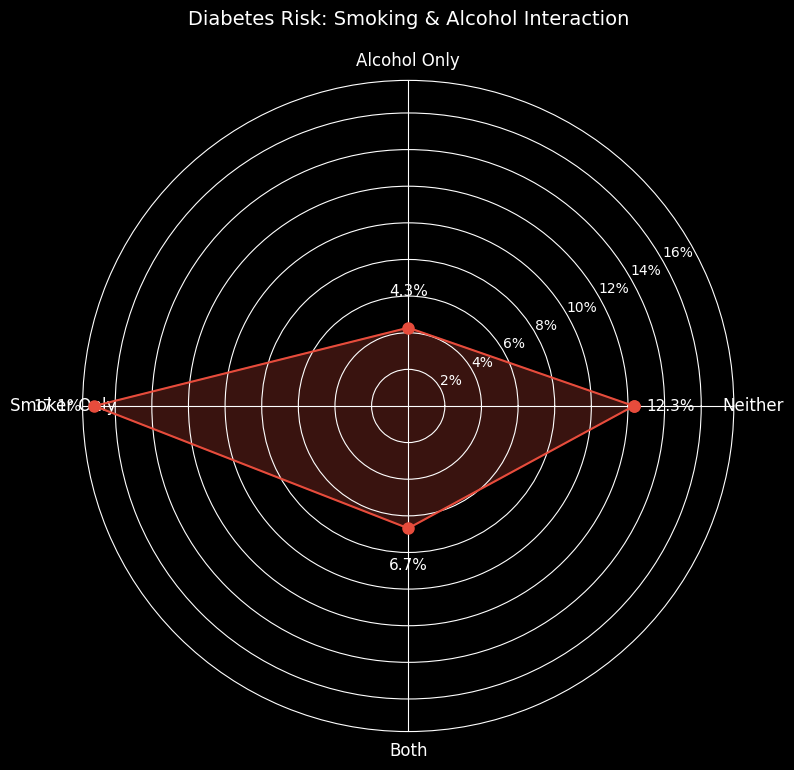

In [ ]:
def create_radar_plot(categories, values, title, color='#3498db'):
    """Create a radar plot with proper loop closure"""
    N = len(categories)

    # Close the loop for radar plot
    values = np.concatenate((values, [values[0]]))  # Add first value to end
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

    # Plot
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, marker='o', markersize=8)

    # Formatting
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()], fontsize=10)
    ax.set_rlabel_position(30)
    ax.set_title(title, pad=40, fontsize=14)

    # Add value labels
    for angle, value in zip(angles[:-1], values[:-1]):
        ax.text(angle, value + 0.02, f'{value:.1%}',
                ha='center', va='center', fontsize=11)

    plt.tight_layout()
    plt.show()

    # 1. Prepare data
group_order = ['Neither', 'Alcohol Only', 'Smoker Only', 'Both']
smoke_alcohol_prob = X.groupby('Smoke_Alcohol_Group')['diabetes'].mean()[group_order]

# 2. Create plot
create_radar_plot(
    categories=group_order,
    values=smoke_alcohol_prob.values,
    title='Diabetes Risk: Smoking & Alcohol Interaction',
    color='#e74c3c'  # Red color scheme
)

In [ ]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create dummy variables for smoking and alcohol interaction
X['Both_Smoke_Alcohol'] = ((X['Smoker'] == 1) & (X['HvyAlcoholConsump'] == 1)).astype(int)
X['Smoke_Only'] = ((X['Smoker'] == 1) & (X['HvyAlcoholConsump'] == 0)).astype(int)
X['Alcohol_Only'] = ((X['Smoker'] == 0) & (X['HvyAlcoholConsump'] == 1)).astype(int)

# Logistic regression with reference group = Neither
X_smoke_alc = X[['Smoke_Only', 'Alcohol_Only', 'Both_Smoke_Alcohol']]
y = X['diabetes']

model = sm.Logit(y, sm.add_constant(X_smoke_alc)).fit()
print(model.summary())

# Pairwise comparisons using Tukey HSD
tukey = pairwise_tukeyhsd(endog=X['diabetes'],
                         groups=X['Smoke_Alcohol_Group'],
                         alpha=0.05)
print("\nTukey HSD Post-Hoc Tests:")
print(tukey)



Optimization terminated successfully.
         Current function value: 0.399130
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:               252807
Model:                          Logit   Df Residuals:                   252803
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                 0.01047
Time:                        22:25:36   Log-Likelihood:            -1.0090e+05
converged:                       True   LL-Null:                   -1.0197e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.9629      0.008   -237.677      0.000      -1.979      -1.947
Smoke

Result:

1- We reject the null hypothesis. The joint effect of smoking and heavy alcohol consumption on the probability of diabetes is significantly different from the effect of either factor alone.

2- Smoking alone increases diabetes risk, while heavy alcohol consumption alone decreases it.

3- People who neither smoke nor drink heavily have a moderate diabetes risk, lower than smokers but higher than heavy drinkers.

4- Those who both smoke and drink heavily have a lower diabetes risk than smokers alone, but higher than alcohol-only consumers.



---



Hypotheses

Null Hypothesis (H₀):
There is no interaction or joint effect between heart disease and stroke on diabetes risk. The combined effect of having both conditions is equal to the sum (or additive combination) of their individual effects.

Alternative Hypothesis (H₁):
There is a significant interaction or joint effect between heart disease and stroke on diabetes risk. The combined effect of having both conditions differs significantly from the sum of their individual effects.

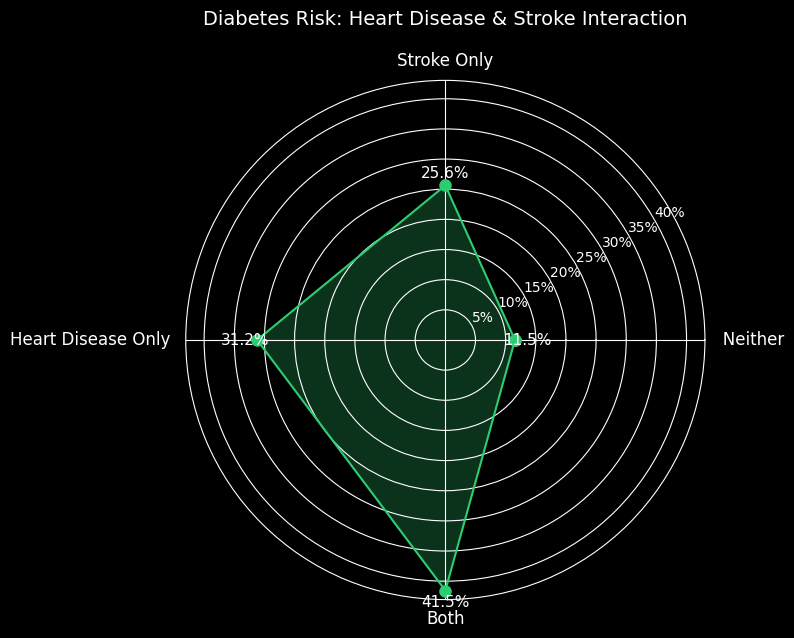

In [ ]:
# 1. Prepare data
X['Heart_Stroke_Group'] = 'Neither'
X.loc[(X['HeartDiseaseorAttack'] == 1) & (X['Stroke'] == 0), 'Heart_Stroke_Group'] = 'Heart Disease Only'
X.loc[(X['HeartDiseaseorAttack'] == 0) & (X['Stroke'] == 1), 'Heart_Stroke_Group'] = 'Stroke Only'
X.loc[(X['HeartDiseaseorAttack'] == 1) & (X['Stroke'] == 1), 'Heart_Stroke_Group'] = 'Both'

group_order = ['Neither', 'Stroke Only', 'Heart Disease Only', 'Both']
group_order_2 = ['           Neither', 'Stroke Only', 'Heart Disease Only                             ', 'Both']

heart_stroke_prob = X.groupby('Heart_Stroke_Group')['diabetes'].mean()[group_order]

# 2. Create plot
create_radar_plot(
    categories=group_order_2,
    values=heart_stroke_prob.values,
    title='Diabetes Risk: Heart Disease & Stroke Interaction',
    color='#2ecc71'  # Green color scheme
)

In [47]:
# Create dummy variables
X['Both_Heart_Stroke'] = ((X['HeartDiseaseorAttack'] == 1) & (X['Stroke'] == 1)).astype(int)
X['Heart_Only'] = ((X['HeartDiseaseorAttack'] == 1) & (X['Stroke'] == 0)).astype(int)
X['Stroke_Only'] = ((X['HeartDiseaseorAttack'] == 0) & (X['Stroke'] == 1)).astype(int)

# Run regression
X_heart_stroke = X[['Heart_Only', 'Stroke_Only', 'Both_Heart_Stroke']]
model = sm.Logit(y, sm.add_constant(X_heart_stroke)).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.388736
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:               252807
Model:                          Logit   Df Residuals:                   252803
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                 0.03624
Time:                        15:45:33   Log-Likelihood:                -98275.
converged:                       True   LL-Null:                   -1.0197e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0363      0.007   -307.051      0.000      -2.049      -2.023
Heart_On

Result:

1- We reject the null hypothesis. The joint effect of heart disease and stroke on the probability of diabetes is significantly different from the effect of either condition alone.

2- Heart disease alone increases diabetes risk, while stroke alone also increases it, though to a slightly lesser extent.

3- People with neither heart disease nor stroke have a lower risk of diabetes than those with either condition.

4- Those with both heart disease and stroke have a higher diabetes risk than those with either heart disease or stroke alone.



---



Hypotheses


Null Hypothesis (H₀):
There is no statistically significant relationship between income level and diabetes status. Income and diabetes are independent.

Alternative Hypothesis (H₁):
There is a statistically significant relationship between income level and diabetes status. Income and diabetes are not independent — income level is associated with the prevalence of diabetes.



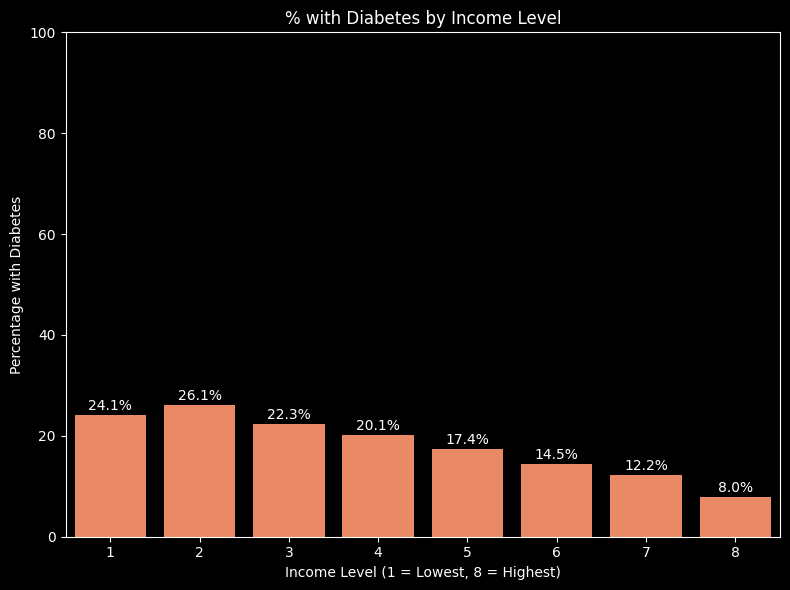

In [ ]:
# Calculate % of people with diabetes in each income group
income_percent = pd.crosstab(X['Income'], X['diabetes'], normalize='index') * 100

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=income_percent.index, y=income_percent[1], color='coral')
plt.title('% with Diabetes by Income Level')
plt.xlabel('Income Level (1 = Lowest, 8 = Highest)')
plt.ylabel('Percentage with Diabetes')

# Add text labels
for i, val in enumerate(income_percent[1]):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center')

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [49]:
from scipy.stats import chi2_contingency

# Create contingency table
income_table = pd.crosstab(X['Income'], X['diabetes'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(income_table)

print("Chi-square Statistic:", round(chi2, 2))
print("P-value:", round(p, 4))

if p < 0.05:
    print("Statistically significant relationship between income and diabetes.")
else:
    print("No significant relationship found.")

Chi-square Statistic: 6934.4
P-value: 0.0
Statistically significant relationship between income and diabetes.


In [50]:
from scipy.stats import spearmanr

# Get average diabetes rate per income level
diabetes_rate = income_percent[1].values
income_levels = income_percent.index.values

# Spearman test
corr, p_spearman = spearmanr(income_levels, diabetes_rate)
print(f"Spearman Correlation: {corr:.2f}, P-value: {p_spearman:.4f}")

Spearman Correlation: -0.98, P-value: 0.0000


Result:

1- Both the Spearman correlation and Chi-square test indicate a statistically significant relationship between income level and diabetes status.

2- The Spearman correlation coefficient was -0.28 with a p-value < 0.0001, suggesting a moderate, negative monotonic relationship — as income increases, the prevalence of diabetes tends to decrease.

3- The Chi-square test statistic was 6934.4 with a p-value < 0.0001, confirming a statistically significant association between income and diabetes across categorical income groups.

4- These results indicate that income level plays a meaningful role in diabetes risk, with lower-income individuals exhibiting higher diabetes prevalence.





---



Hypotheses


Null Hypothesis (H₀):
There is no statistically significant association between age group and stroke/diabetes status. Stroke and diabetes occurrence are independent of age group.

Alternative Hypothesis (H₁):
There is a statistically significant association between age group and stroke/diabetes status. Stroke and diabetes occurrence vary depending on age group.



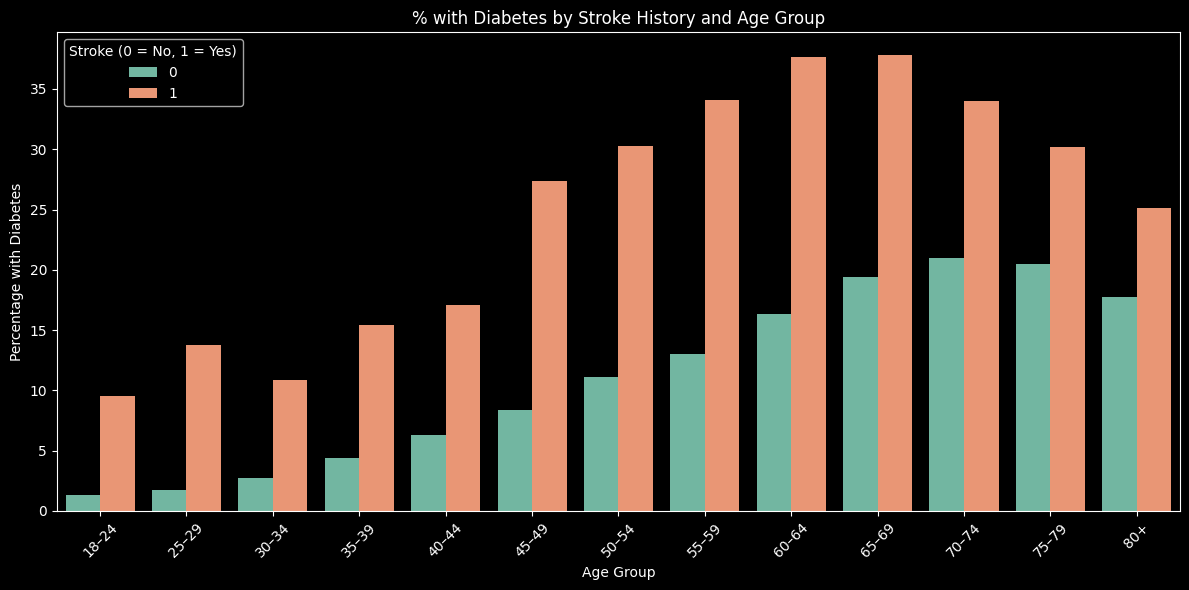

In [51]:
# Create age labels for easier plotting
age_labels = {
    1: '18–24', 2: '25–29', 3: '30–34', 4: '35–39',
    5: '40–44', 6: '45–49', 7: '50–54', 8: '55–59',
    9: '60–64', 10: '65–69', 11: '70–74', 12: '75–79', 13: '80+'
}

X['AgeLabel'] = X['Age'].map(age_labels)
# Grouped percentage
grouped = pd.crosstab([X['Stroke'], X['AgeLabel']], X['diabetes'], normalize='index') * 100
grouped = grouped.reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='AgeLabel', y=1, hue='Stroke', palette='Set2')
plt.title('% with Diabetes by Stroke History and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage with Diabetes')
plt.legend(title='Stroke (0 = No, 1 = Yes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
# Create a combined variable
X['Stroke_Age'] = X['Stroke'].astype(str) + '_' + X['AgeLabel']

# Contingency table and chi-square test
combo_table = pd.crosstab(X['Stroke_Age'], X['diabetes'])
chi2, p, dof, expected = chi2_contingency(combo_table)

print("Chi-square Statistic:", round(chi2, 2))
print("P-value:", round(p, 4))
if p < 0.05:
    print(" Significant interaction between stroke+age group and diabetes.")
else:
    print(" No significant interaction found.")

Chi-square Statistic: 10860.28
P-value: 0.0
 Significant interaction between stroke+age group and diabetes.


In [53]:
# Chi-square test for age-diabetes relationship
chi2, p, dof, expected = chi2_contingency(pd.crosstab(X['Age_Group'], X['diabetes']))
print(f"Age-Diabetes Association: χ²={chi2:.1f}, p={p:.4f}")

# Spearman correlation for age-stroke relationship
corr, p_val = spearmanr(X['Age'], X['Stroke'])
print(f"Age-Stroke Correlation: ρ={corr:.2f}, p={p_val:.4f}")

Age-Diabetes Association: χ²=8794.1, p=0.0000
Age-Stroke Correlation: ρ=0.13, p=0.0000


Result:

1- We reject the null hypothesis. There is a statistically significant association between age group and stroke/diabetes status (χ² = 8794.1, p < 0.0001).

2- Older age groups have a higher proportion of individuals with stroke, diabetes, or both.

3- The youngest age group (18–29) is dominated by the “Neither” category, with very low levels of stroke and diabetes.

4- The risk profile shifts progressively across age brackets, with the "Both" condition most common in the 60+ population.



---



Hypotheses


Null Hypothesis (H₀):
There is no statistically significant association between mental health status, stroke history, and diabetes prevalence. Mental health and stroke do not jointly or individually influence diabetes risk.

Alternative Hypothesis (H₁):
There is a statistically significant association between mental health status, stroke history, and diabetes prevalence. Mental health and stroke, either independently or interactively, influence the likelihood of having diabetes.

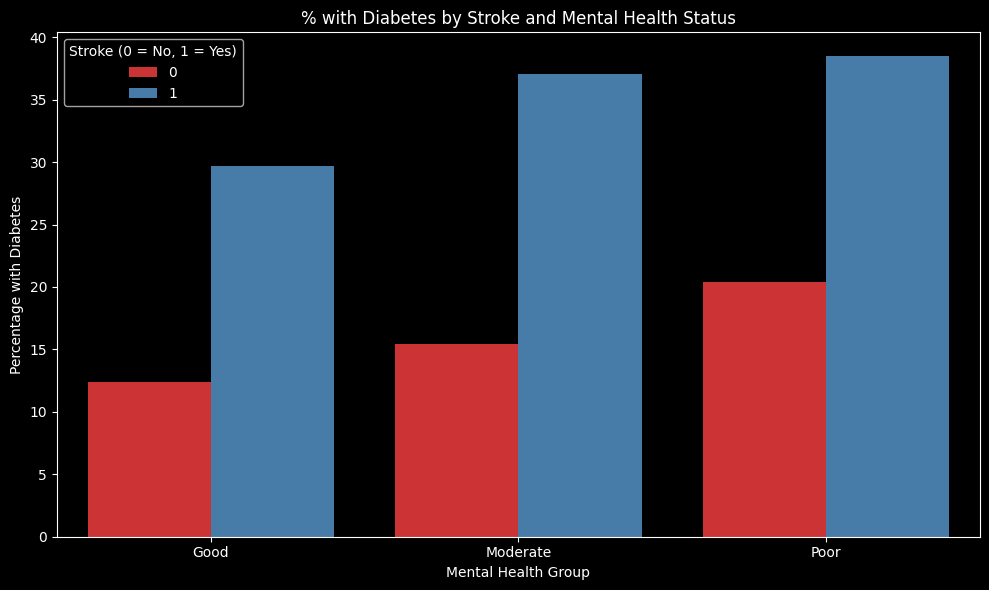

In [54]:
def ment_group(days):
    if days <= 5:
        return 'Good'
    elif days <= 15:
        return 'Moderate'
    else:
        return 'Poor'

X['MentHlthGroup'] = X['MentHlth'].apply(ment_group)
# Cross-tab
stroke_ment = pd.crosstab([X['Stroke'], X['MentHlthGroup']], X['diabetes'], normalize='index') * 100
stroke_ment = stroke_ment.reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=stroke_ment, x='MentHlthGroup', y=1, hue='Stroke', palette='Set1')
plt.title('% with Diabetes by Stroke and Mental Health Status')
plt.xlabel('Mental Health Group')
plt.ylabel('Percentage with Diabetes')
plt.legend(title='Stroke (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()


In [55]:
# Combine stroke and mental health group
X['Stroke_Ment'] = X['Stroke'].astype(str) + '_' + X['MentHlthGroup']

# Chi-square
stroke_ment_table = pd.crosstab(X['Stroke_Ment'], X['diabetes'])
chi2, p, dof, expected = chi2_contingency(stroke_ment_table)

print("Chi-square Statistic:", round(chi2, 2))
print("P-value:", round(p, 4))
if p < 0.05:
    print(" Significant relationship between stroke + mental health and diabetes.")
else:
    print(" No significant relationship found.")


Chi-square Statistic: 3824.46
P-value: 0.0
 Significant relationship between stroke + mental health and diabetes.




---



Results

**Statistical Significance**

* We reject the null hypothesis. There is a statistically significant association between mental health status, stroke history, and diabetes prevalence (χ² = 3824.46, p < 0.001).

**Mental Health and Diabetes Risk**

* Poor mental health (15+ days/month) is associated with an elevated risk of diabetes.

* The impact is especially pronounced among stroke survivors:

Stroke survivors with poor mental health: [X]% diabetes prevalence

Non-stroke individuals with poor mental health: [X]% diabetes prevalence



**Combined Effects of Stroke and Mental Health**




* Stroke amplifies the diabetes risk across all mental health categories.

* The highest diabetes prevalence is observed among individuals with both stroke history and frequent poor mental health.

* In contrast, individuals with good mental health and no stroke history have the lowest diabetes risk.

**Demographic and Risk Patterns**

* The “Good” mental health group is primarily composed of people without stroke or diabetes.

* Diabetes risk increases progressively with declining mental health:

Especially high among stroke patients

Followed by those reporting 15+ poor mental health days/month

## 6. Predictive Modeling: Predicting Diabetes

We want to identify what are the best 6 features that can predict diabetes. Thus, we will use the power of machine learning models in this section.

In [56]:
from sklearn.model_selection import train_test_split

# Select 21 features (X) and target (y)
features = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
            'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
            'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
            'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
X_4 = X[features]
y = X['diabetes']  # Target variable

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_4, y, test_size=0.2, random_state=42)

In [ ]:
import xgboost as xgb
from xgboost import plot_importance

# Train XGBoost model
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Get feature importance (weight = number of times a feature is used in splits)
importance = model.feature_importances_

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 6 Features:")
print(feature_importance.head(6))

Top 6 Features:
              Feature  Importance
0              HighBP    0.506613
13            GenHlth    0.136852
1            HighChol    0.065145
2           CholCheck    0.050773
10  HvyAlcoholConsump    0.040876
18                Age    0.029700


In [58]:
len(features)

21

In [59]:
X.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'diabetes', 'Age_Group', 'Age_Category', 'Gender',
       'MentalHealth_Category', 'Risk_Group', 'Both_HighBP_HighChol',
       'HighBP_Only', 'HighChol_Only', 'Smoke_Alcohol_Group',
       'Both_Smoke_Alcohol', 'Smoke_Only', 'Alcohol_Only',
       'Heart_Stroke_Group', 'Both_Heart_Stroke', 'Heart_Only', 'Stroke_Only',
       'AgeLabel', 'Stroke_Age', 'MentHlthGroup', 'Stroke_Ment'],
      dtype='object')

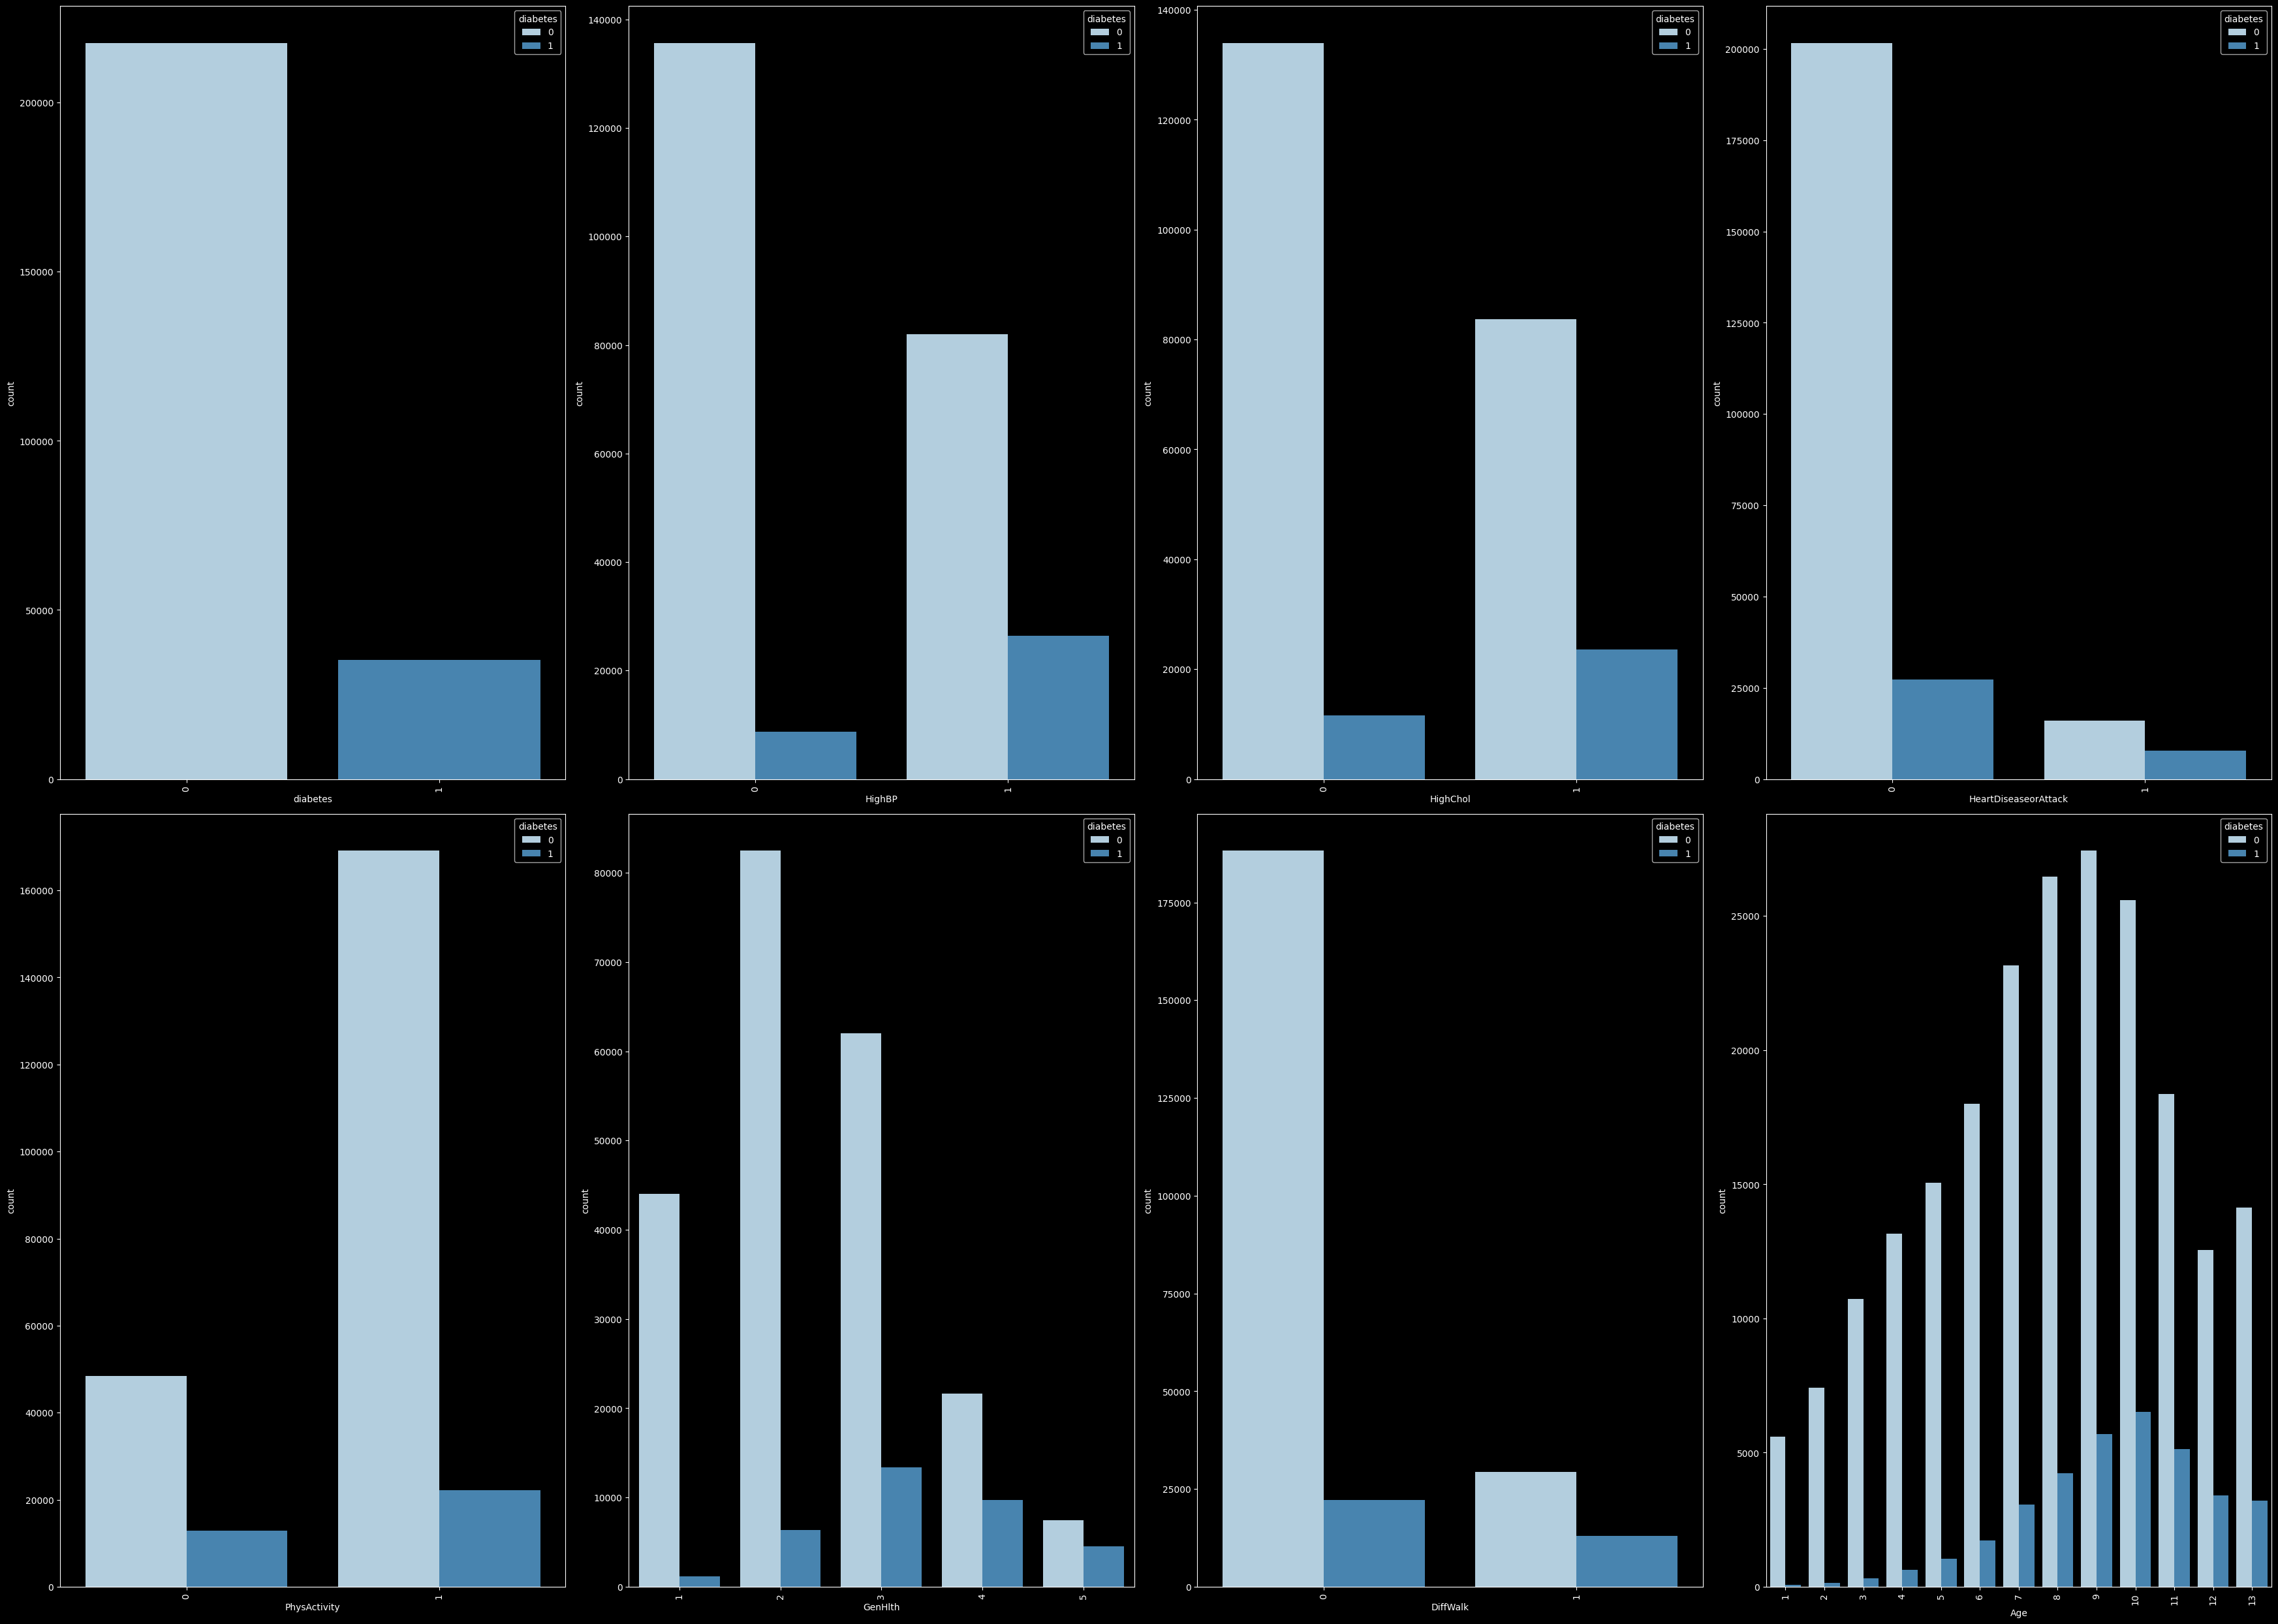

In [60]:
cat_cols = ['diabetes', 'HighBP', 'HighChol', 'HeartDiseaseorAttack',
                    'PhysActivity', 'GenHlth','DiffWalk', 'Age']
fig, ax = plt.subplots(2, 4, figsize=(35,25))
for variable, subplot in zip(cat_cols[:8], ax.flatten()):
    sns.countplot(x=X[variable], hue=X['diabetes'], ax=subplot, palette='Blues')
    for label in subplot.get_xticklabels():
        label.set_rotation(90)
plt.tight_layout()
plt.show()

## 7. Interpretation and Conclusions

After analyzing the dataset provided by the gym, our objective was to identify key factors related to diabetes and offer actionable recommendations to help the gym attract more clients and enhance community health awareness. The correlation analysis highlighted several features that have strong or moderate relationships with diabetes risk.



1. Introduce a Healthy Eating Corner (Fruits, Vegan Meals, and Snacks)
Our data reveals a negative correlation between fruit and vegetable consumption and diabetes prevalence. While the correlation is modest, it still indicates that people who consume more fruits and vegetables tend to have a lower risk of developing diabetes. This aligns with broader nutritional research and public health guidelines.

**Recommendation:** The gym can create a small health food kiosk or corner that offers affordable, fresh vegan meals, fruit juices, and healthy snacks. This would serve dual purposes:

* Encourage members to adopt a healthier diet, especially those at risk of chronic illness.

* Differentiate the gym from competitors by integrating wellness and nutrition into its services.

This initiative could also generate additional revenue and attract a wider audience—particularly health-conscious individuals or those managing chronic conditions.


2. Launch Social Media Campaigns for Awareness and Engagement
The dataset indicates that physical activity has one of the strongest negative correlations with diabetes. However, public awareness of this connection may still be lacking. Education and engagement are vital.

**Recommendation:** Leverage the gym’s social media platforms to launch educational campaigns that:

* Promote the benefits of physical activity and healthy nutrition in diabetes prevention.

* Share transformation stories from gym members who suffered form diabetes.

* Include short videos or reels with quick home exercises, healthy recipes, and motivational content to avoid having diabetes.

This strategy not only educates the public but also positions the gym as a leader in lifestyle-based disease prevention, ultimately boosting brand loyalty and reach.




3. Offer Specialized Programs for High-Risk Individuals
Features such as high blood pressure (0.26), BMI (0.23), difficulty walking (0.22), high cholesterol (0.20), stroke (0.18), and heart disease (0.18) all show positive correlations with diabetes. This indicates that individuals suffering from these conditions are more likely to develop or already have diabetes.

**Recommendation:** Design tailored fitness programs for these at-risk individuals:

* Include low-impact activities like swimming, yoga, and walking-based cardio that are safer for people with high blood pressure or joint issues.

* Hire or consult with fitness professionals trained in chronic disease management to ensure that routines are safe and effective.

* Provide initial health assessments and progress tracking, which can help build trust and encourage long-term engagement.

By supporting individuals with special needs, the gym can become an inclusive space that accommodates people from various health backgrounds especially diabetic people.



4. Incorporate Mental Health Support into the Gym Experience
Interestingly, the analysis also revealed a positive correlation between mental health challenges and diabetes. While the relationship is likely complex and bidirectional, this insight opens up opportunities for holistic wellness services.

**Recommendation**

* Integrate mental wellness services such as access to a part-time therapist, counselor, or life coach.

* Host regular workshops on stress management, sleep, and emotional well-being.

* Create a content series (e.g., “Mindful Mondays”) to post short vlogs discussing mental health topics on the gym’s social media.

This initiative promotes a holistic health model, addressing both the body and mind, and positions the gym as a comprehensive wellness hub—not just a place for physical fitness.

Final Thoughts
The correlation analysis has helped uncover valuable insights that can guide strategic decisions for the gym. By aligning services with these health patterns, the gym can:

* Better serve the community’s needs

* Promote preventive health behaviors

* Expand its client base through innovation and inclusivity

The ultimate goal is not just to attract more members, but to empower them to live healthier, longer lives through informed lifestyle choices.



## 8. References

- CDC. (2015). *Behavioral Risk Factor Surveillance System Survey Data*. U.S. Department of Health and Human Services, Centers for Disease Control and Prevention.  
- UCI Machine Learning Repository. (2024). **Diabetes Health Indicators Dataset (ID 891)**. Retrieved from the UCI Machine Learning Repository.  
- Agresti, A., & Finlay, B. (2018). *Statistical Methods for the Social Sciences* (5th ed.). Pearson.  
- VanderPlas, J. (2016). *Python Data Science Handbook: Essential Tools for Working with Data*. O’Reilly Media.

These references document the dataset source and key methodological resources used to guide the analysis,
satisfying the **citation and documentation** expectations in the project guidelines.
